In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

In [2]:
SEED = 42
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE = 3
MIN_DELTA = 0.001
NUM_CLASSES = 4

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

# 데이터 증강 및 전처리
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

data_path = '/content/drive/MyDrive/Colab Notebooks/뇌종양 분류'
train_path = os.path.join(data_path, 'Training')
val_path = os.path.join(data_path, 'Testing')

train_data = datasets.ImageFolder(root=train_path, transform=train_transform)
val_data = datasets.ImageFolder(root=val_path, transform=val_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [4]:
# ResNet18 모델 로드 (Pretrained weights 사용)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 마지막 FC 레이어를 뇌종양 4개 클래스에 맞게 변경
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

# 손실함수 및 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# 스케줄러 정의 (학습이 진행됨에 따라 에폭에 맞춰 러닝레이트를 부드럽게 깎아줌)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]


In [5]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
early_stop_counter = 0

for epoch in range(NUM_EPOCHS):
    print(f'\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---')

    model.train()
    running_loss = 0.0
    running_corrects = 0

    train_pbar = tqdm(train_loader, desc=f"Train Epoch {epoch+1}")
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)

        train_pbar.set_postfix(loss=loss.item())

    epoch_train_loss = running_loss / len(train_data)
    epoch_train_acc = running_corrects.double() / len(train_data)

    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0

    val_pbar = tqdm(val_loader, desc=f"Val Epoch {epoch+1}")
    with torch.no_grad():
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_val_corrects += torch.sum(preds == labels.data)

            val_pbar.set_postfix(loss=loss.item())

    epoch_val_loss = running_val_loss / len(val_data)
    epoch_val_acc = running_val_corrects.double() / len(val_data)

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc.item())
    history['val_acc'].append(epoch_val_acc.item())

    print(f'Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}')
    print(f'Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.4f}')

    scheduler.step()

    if epoch_val_acc > (best_val_acc + MIN_DELTA):
        print(f'Validation Accuracy 개선: ({best_val_acc:.4f} --> {epoch_val_acc:.4f}). 모델 가중치 저장.')
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_brain_tumor_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(f'EarlyStopping 카운터 증가: {early_stop_counter} / {PATIENCE}')
        if early_stop_counter >= PATIENCE:
            print(f'최적의 성능에 도달하여 조기 종료합니다. Best Val Acc: {best_val_acc:.4f}')
            break


--- Epoch 1/20 ---


Train Epoch 1:   0%|          | 0/90 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Val Epoch 1: 100%|██████████| 13/13 [01:02<00:00,  4.79s/it, loss=0.0284]


Train Loss: 0.3521 | Train Acc: 0.8666
Val   Loss: 1.2670 | Val   Acc: 0.7081
Validation Accuracy 개선: (0.0000 --> 0.7081). 모델 가중치 저장.

--- Epoch 2/20 ---


Val Epoch 2: 100%|██████████| 13/13 [00:38<00:00,  2.93s/it, loss=0.101]


Train Loss: 0.1232 | Train Acc: 0.9551
Val   Loss: 1.6121 | Val   Acc: 0.7056
EarlyStopping 카운터 증가: 1 / 3

--- Epoch 3/20 ---


...

Train Loss: 0.0205 | Train Acc: 0.9951
Val   Loss: 1.8572 | Val   Acc: 0.7665
EarlyStopping 카운터 증가: 1 / 3

--- Epoch 8/20 ---


Val Epoch 8: 100%|██████████| 13/13 [00:38<00:00,  2.99s/it, loss=0.00249]


Train Loss: 0.0194 | Train Acc: 0.9948
Val   Loss: 1.5236 | Val   Acc: 0.7563
EarlyStopping 카운터 증가: 2 / 3

--- Epoch 9/20 ---


Val Epoch 9: 100%|██████████| 13/13 [00:38<00:00,  2.94s/it, loss=0.00217]

Train Loss: 0.0115 | Train Acc: 0.9972
Val   Loss: 1.5371 | Val   Acc: 0.7690
EarlyStopping 카운터 증가: 3 / 3
최적의 성능에 도달하여 조기 종료합니다. Best Val Acc: 0.7716


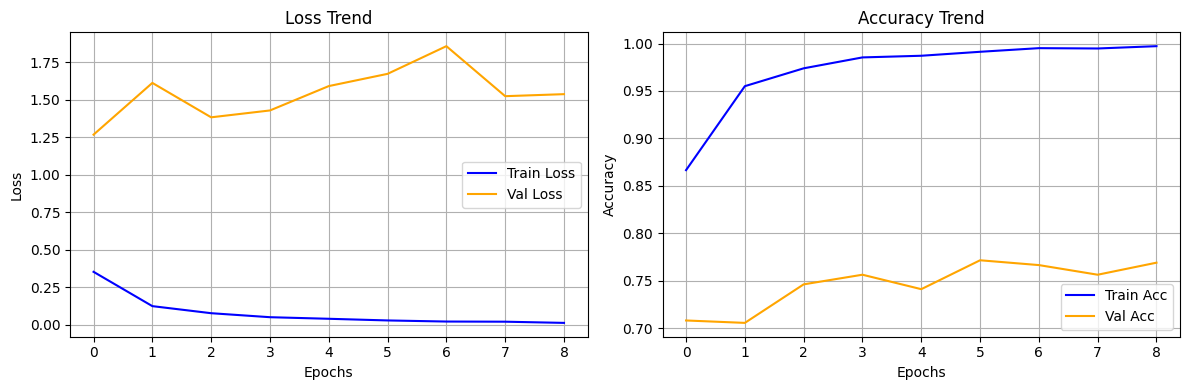

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss Trend')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='blue')
plt.plot(history['val_acc'], label='Val Acc', color='orange')
plt.title('Accuracy Trend')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


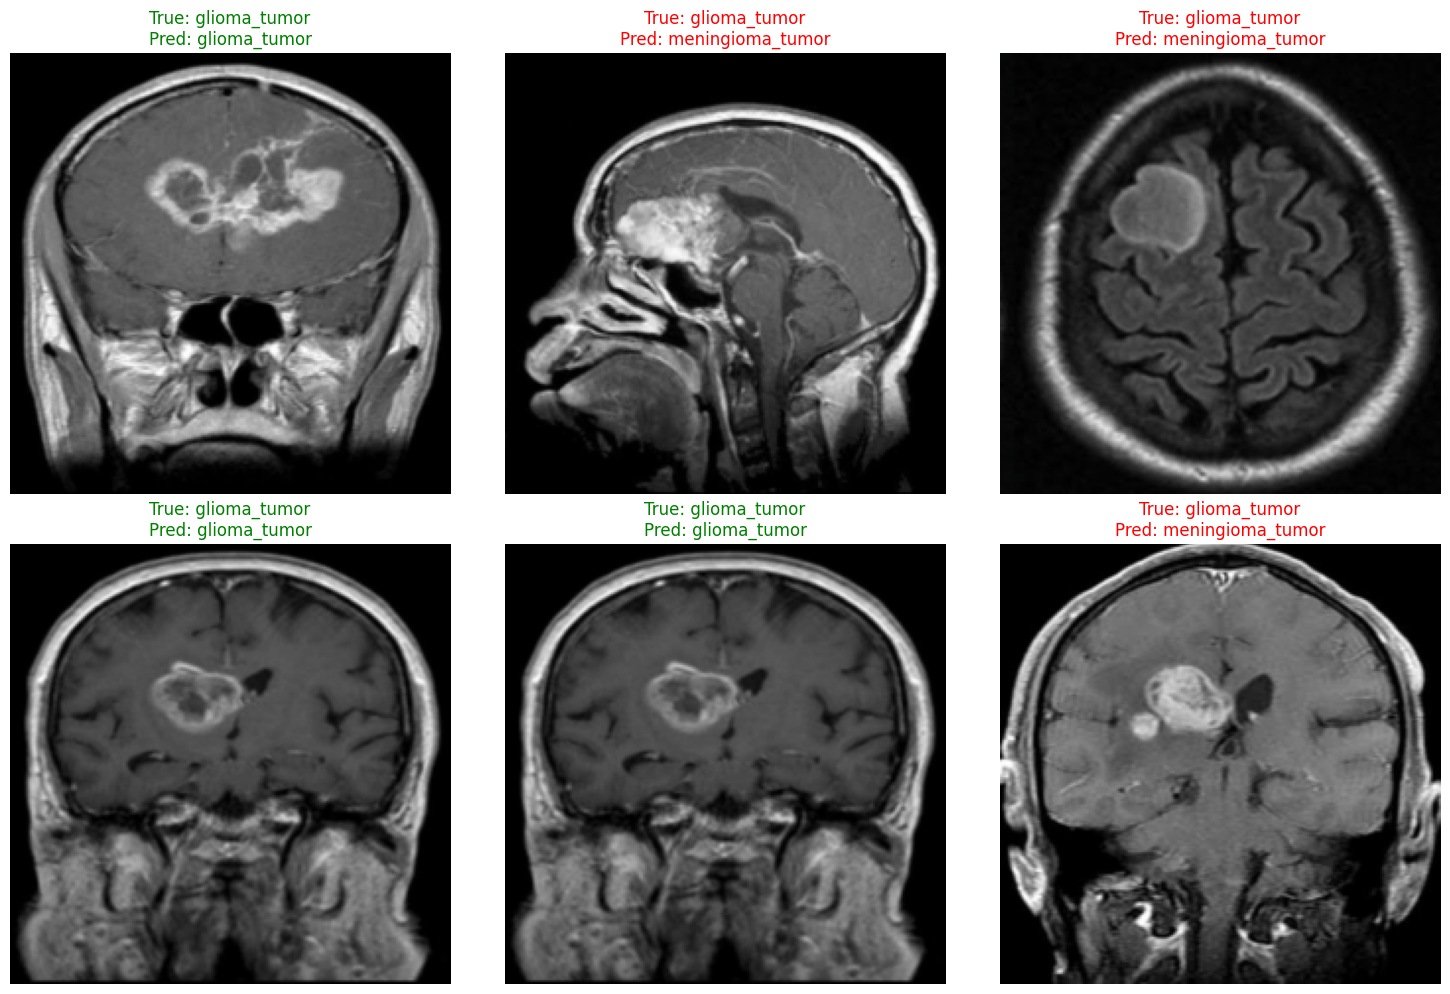

In [10]:
def visualize_predictions(model, val_loader, device, num_images=6):
  model.eval()

  idx_to_class = {v: k for k, v in val_loader.dataset.class_to_idx.items()}

  images_shown = 0
  plt.figure(figsize=(15, 10))

  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)

      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)

      for i in range(inputs.size(0)):
        if images_shown >= num_images:
          break

        images_shown += 1
        ax = plt.subplot(2, num_images // 2 + (num_images % 2), images_shown)
        ax.axis('off')

        img = inputs[i].cpu().numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        actual_label = idx_to_class[labels[i].item()]
        predicted_label = idx_to_class[preds[i].item()]

        color = 'green' if actual_label == predicted_label else 'red'

        ax.imshow(img)
        ax.set_title(f'True: {actual_label}\nPred: {predicted_label}', color=color, fontsize=12)

      if images_shown >= num_images:
        break

  plt.tight_layout()
  plt.show()

visualize_predictions(model, val_loader, device, num_images=6)

In [11]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 35.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=196216dad0c9cb12c0add8d9a708c75ccb182fd353b3e6de97efb6f0e023cbfc
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


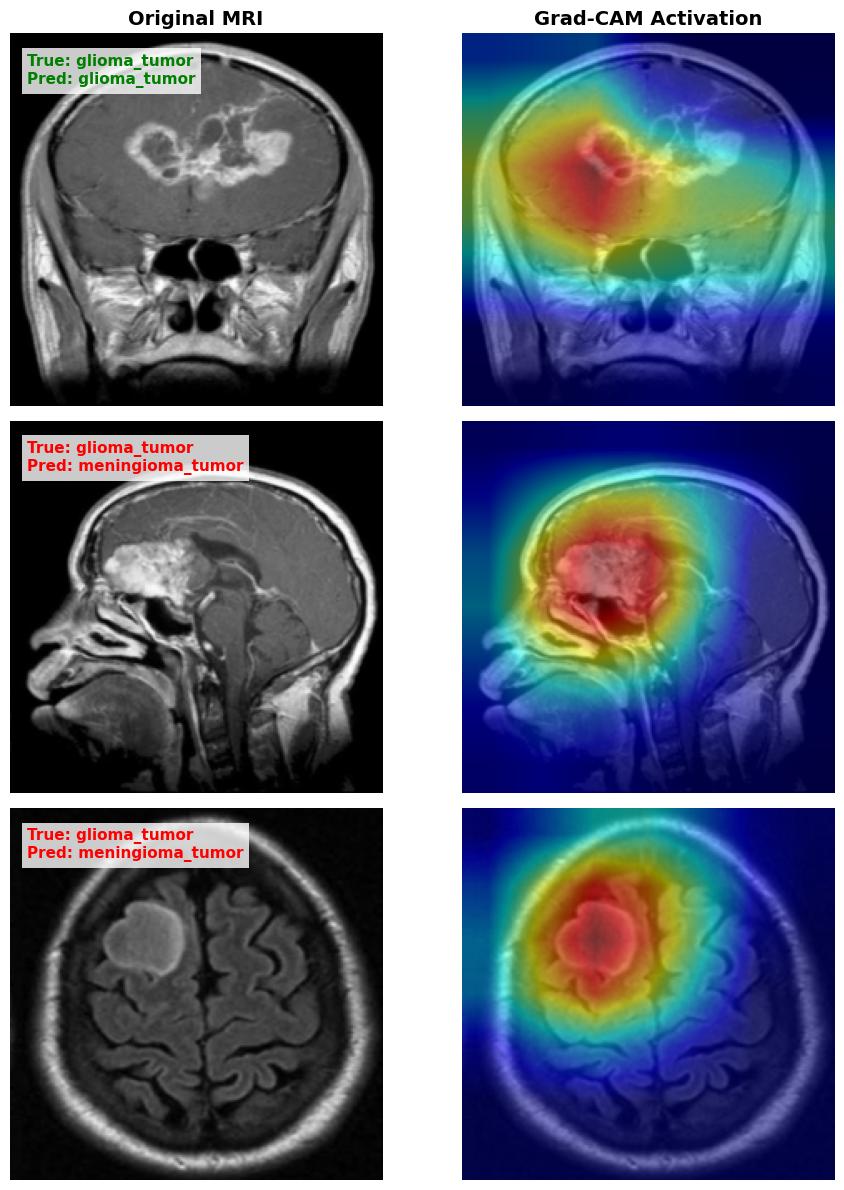

In [12]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def show_gradcam_results(model, val_loader, device, num_images=3):
  model.eval()

  target_layers = [model.layer4[-1]]

  cam_extractor = GradCAM(model=model, target_layers=target_layers)

  idx_to_class = {v: k for k, v in val_loader.dataset.class_to_idx.items()}

  inputs, labels = next(iter(val_loader))
  inputs, labels = inputs.to(device), labels.to(device)

  outputs = model(inputs)
  _, preds = torch.max(outputs, 1)

  plt.figure(figsize=(10, 4 * num_images))

  for i in range(num_images):
    input_tensor = inputs[i].unsqueeze(0)

    img_np = inputs[i].cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    target_category = preds[i].item()
    targets = [ClassifierOutputTarget(target_category)]

    grayscale_cam = cam_extractor(input_tensor=input_tensor, targets=targets)[0, :]

    gradcam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    actual_label = idx_to_class[labels[i].item()]
    predicted_label = idx_to_class[target_category]
    color = 'green' if actual_label == predicted_label else 'red'

    ax1 = plt.subplot(num_images, 2, i * 2 + 1)
    ax1.imshow(img_np)
    ax1.axis('off')
    if i == 0: ax1.set_title("Original MRI", fontsize=14, fontweight='bold')

    ax1.text(10, 30, f'True: {actual_label}\nPred: {predicted_label}', color=color, fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    ax2 = plt.subplot(num_images, 2, i * 2 + 2)
    ax2.imshow(gradcam_image)
    ax2.axis('off')
    if i == 0: ax2.set_title("Grad-CAM Activation", fontsize=14, fontweight='bold')

  plt.tight_layout()
  plt.show()

show_gradcam_results(model, val_loader, device, num_images=3)